In [51]:
# Imports

import numpy as np
import matplotlib.pyplot as plt

%matplotlib ipympl
%matplotlib inline


In [11]:
## Echauffement

a = np.array([1,2,3])

#1) a est de forme (3) => a[:,None] est de forme (3,1)
# a est de forme (3) => a[None,:] est de forme (1,3)

#2) a[:, None] - a[None, :] => de forme (3,3) 
# on obtient le résultat de : [[1,1,1],[2,2,2],[3,3,3]] - [[1,2,3],[1,2,3],[1,2,3]]
print(a[:, None] - a[None, :])
print(np.array([[1,1,1],[2,2,2],[3,3,3]]) - np.array([[1,2,3],[1,2,3],[1,2,3]]))

# On a bien la même chose, on généralise : 
# RES[i,j]=a[i]-a[j]


#3) b est de forme (2,3)
# => b[:,None,:] est de forme (2,1,3)
# => b[:,:,None] est de forme (2,3,1)
# 
# => RES = b[:,None,:] - b[:,:,None] est de forme (2,3,3)
#
# RES[i,j,k] = b[:,None,:][i][1][k] - b[:,:,None][i][j][1]
#            = b[i][k] - b[i][j]



[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]
[[ 0 -1 -2]
 [ 1  0 -1]
 [ 2  1  0]]


In [23]:
## Initialisation aléatoire

# les bornes pour le tirage au sort initial
mass_max = 3.
    
x_min, x_max = -10., 10.
y_min, y_max = -10., 10.

speed_max = 1.



def init_problem(N):
    """
    retourne un tuple masses, positions, speeds
    de formes resp.   (N,)    (2, N)     (2, N)
    tiré au sort dans les bornes définies ci-dessus
    """
    masses=np.random.uniform(0, mass_max, (N,))
    positions=np.random.uniform(np.array([[x_min],[y_min]]), np.array([[x_max],[y_max]]), (2,N))
    speeds=np.random.uniform(-speed_max, speed_max, (2,N))

    return masses, positions, speeds

print(init_problem(5))

(array([1.20469906, 1.81075755, 2.60503163, 1.63125987, 2.13986193]), array([[ 5.84607965,  6.40100267, -0.68237711,  4.52071249, -9.31255627],
       [ 6.38826542,  9.25313771, -2.07759015, -8.68857135, -4.42716504]]), array([[ 0.66117705,  0.28688404,  0.58268192,  0.38159128, -0.47585346],
       [ 0.26259462, -0.60924153,  0.53793459,  0.30903643, -0.82044839]]))


In [22]:
## Initialisation reproductible

def init3():
    # first element is sun-like: heavy, at the center, and no speed
    masses = np.array([3, 1, 1], dtype=float)
    positions = np.array([
        [0, 5, -5], 
        [0, 1, -1]], dtype=float)
    speeds = np.array([
        [0, -1, 1], 
        [0, 0, 0]], dtype=float)
    return masses, positions, speeds



In [34]:
## Les forces


def forces(masses, positions, G=1.0):
    """
    returns an array of shape (2,  N)
    that contains the force felt by each mass from all the others
    G is the Newton constant and by default is set to 1 
    (we have abstract units anyway)
    """

    diff=positions[:,:,None]-positions[:,None,:]
    dist=np.linalg.norm(diff, axis=0)
    
    np.fill_diagonal(dist,np.inf)
    
    coeff=G*masses[:,None]*masses[None,:]
    C=coeff[None,:,:]
        
    F=np.sum(C*diff/(dist**3), axis=1)

    
    return F

print(forces(init3()[0],init3()[1]))


[[ 0.         -0.12257258  0.12257258]
 [ 0.         -0.02451452  0.02451452]]


In [42]:
## Le simulateur

def simulate(masses, positions, speeds, dt=0.1, nb_steps=100):
    """
    should return the positions across time
    so an array of shape (nb_steps, 2, N)
    optional dt is the time step
    """
    N=len(masses)
    dim=len(positions)
    res=np.zeros((nb_steps,dim,N))

    m=masses[None,:]
    res[0]=positions

    for i in range(nb_steps):
        F=forces(masses,positions)
        a=F/m
        speeds=speeds+a*dt
        positions=positions+speeds*dt
        res[i]=positions
    return res

print(simulate(init3()[0],init3()[1],init3()[2]))



[[[ 0.          4.89877427 -4.89877427]
  [ 0.          0.99975485 -0.99975485]]

 [[ 0.          4.79627468 -4.79627468]
  [ 0.          0.99924973 -0.99924973]]

 [[ 0.          4.69244953 -4.69244953]
  [ 0.          0.99846845 -0.99846845]]

 [[ 0.          4.58724324 -4.58724324]
  [ 0.          0.99739329 -0.99739329]]

 [[ 0.          4.48059587 -4.48059587]
  [ 0.          0.99600479 -0.99600479]]

 [[ 0.          4.37244262 -4.37244262]
  [ 0.          0.99428155 -0.99428155]]

 [[ 0.          4.26271324 -4.26271324]
  [ 0.          0.99219989 -0.99219989]]

 [[ 0.          4.15133136 -4.15133136]
  [ 0.          0.98973361 -0.98973361]]

 [[ 0.          4.03821371 -4.03821371]
  [ 0.          0.98685348 -0.98685348]]

 [[ 0.          3.92326914 -3.92326914]
  [ 0.          0.9835269  -0.9835269 ]]

 [[ 0.          3.80639758 -3.80639758]
  [ 0.          0.97971724 -0.97971724]]

 [[ 0.          3.68748865 -3.68748865]
  [ 0.          0.97538319 -0.97538319]]

 [[ 0.          

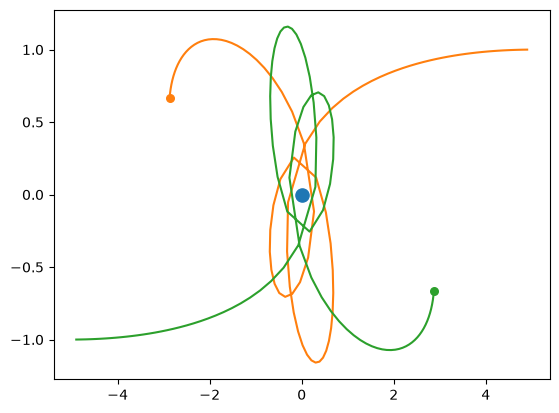

In [63]:
## Dessiner



def draw(simulation, masses, colors=None, scale=10.):
    """
    takes as input the result of simulate() above,
    and draws the nb_steps positions of each of the N bodies
    ideally it should return a matplotlib Axes object

    one can provide a collection of N colors to use for each body
    if not provided this is randomized

    also the optional scale parameter is used as a constant
    multiplier to obtain the final size of each dot on the figure
    """
    fig,ax=plt.subplots()
    for i in range(len(masses)):
        X,Y=simulation[:,:,i].T[0],simulation[:,:,i].T[1]
    
        plt.plot(X,Y)
        ax.scatter(X[-1],Y[-1],s=30*masses[i])

    plt.show()


    pass

draw(simulate(init3()[0],init3()[1],init3()[2]),init3()[0])

In [ ]:
# liste de jolies couleurs :)

colors3 = np.array([
    [32, 32, 32],
    (228, 90, 146),
    (111, 0, 255),
]) / 255
